In [2]:
import pandas as pd                         
import numpy as np                           
import matplotlib.pyplot as plt              
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
from sklearn.model_selection import train_test_split

In [3]:
df = pd.read_csv('../data/cleaned.csv')
df.shape


(7043, 20)

In [4]:
x= df.drop('Churn',axis=1)
y=df['Churn']

In [5]:
x_train,x_test,y_train,y_test=train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42
) 

In [6]:
num_cols = x_train.select_dtypes(
    include=['int64', 'float64']
).columns.tolist()

cat_cols = x_train.select_dtypes(
    include=['object', 'category']
).columns.tolist()

print("Colonnes numériques :", num_cols)
print("Colonnes catégorielles :", cat_cols)

Colonnes numériques : ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
Colonnes catégorielles : ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


/tmp/ipykernel_5276/589592170.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = x_train.select_dtypes(


In [7]:
prep = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), cat_cols)
    ]  
)
x_train_scaled= prep.fit_transform(x_train)
x_test_scaled= prep.transform(x_test)
feature_names = prep.get_feature_names_out()
print(f"Nombre de features après preprocessing : {x_train_scaled.shape[1]}")
print("Noms des premières features :", feature_names[:5])

Nombre de features après preprocessing : 23
Noms des premières features : ['num__SeniorCitizen' 'num__tenure' 'num__MonthlyCharges'
 'num__TotalCharges' 'cat__gender_Male']


In [8]:
k_range= range(2,11)
cl = []

for k in k_range:
    kmeans= KMeans(n_clusters=k,random_state=42,n_init=10)
    labels=kmeans.fit_predict(x_train_scaled)
    sil = silhouette_score(x_train_scaled,labels)
    davies= davies_bouldin_score(x_train_scaled,labels)
    cal = calinski_harabasz_score(x_train_scaled,labels)

    cl.append({
        'k':k,
        'silhouette':sil,
        'davies_bouldin':davies,
        'calinski_harabasz':cal
    })

res = pd.DataFrame(cl)
res

,k,silhouette,davies_bouldin,calinski_harabasz
0,2,0.244767,1.606297,1983.888899
1,3,0.197982,1.779022,1624.299761
2,4,0.205412,1.614739,1504.261207
3,5,0.185650,1.635737,1312.245632
4,6,0.188905,1.608647,1204.426492
5,7,0.184879,1.675187,1122.456636
6,8,0.166186,1.825263,1035.952515
7,9,0.156321,1.916293,961.464673
8,10,0.151241,1.919906,893.445763


In [9]:
min_s=10

nn=NearestNeighbors(n_neighbors=min_s)
nn.fit(x_train_scaled)

distance, indices=nn.kneighbors(x_train_scaled)

k_dis= distance[:,-1]

k_dis_sorted= np.sort(k_dis)

/tmp/ipykernel_5276/1710632774.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


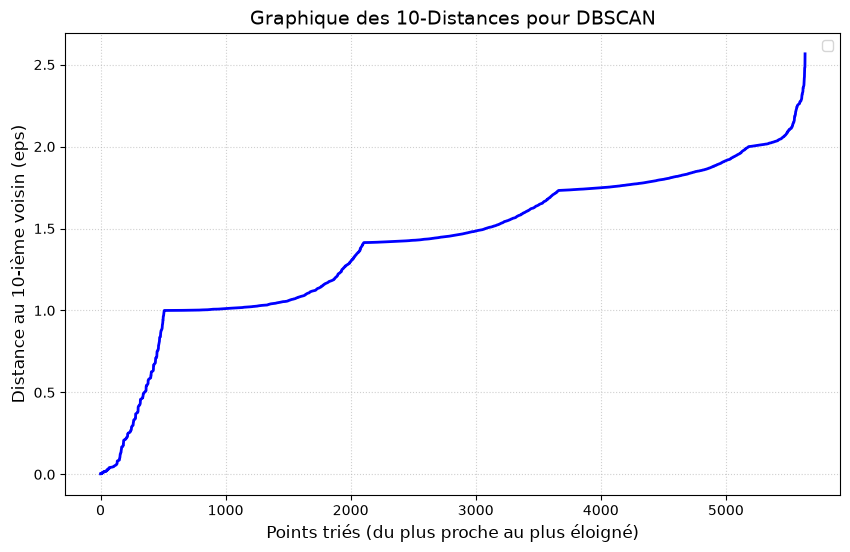

In [10]:
plt.figure(figsize=(10, 6))
plt.plot(k_dis_sorted, color='blue', linewidth=2)
plt.title(f'Graphique des {min_s}-Distances pour DBSCAN', fontsize=14)
plt.xlabel('Points triés (du plus proche au plus éloigné)', fontsize=12)
plt.ylabel(f'Distance au {min_s}-ième voisin (eps)', fontsize=12)

plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.show()

In [11]:
min_samples_fixed = 10
eps_range = np.arange(1.0, 2.6, 0.1)  
db_list = []

for eps in eps_range:
    db = DBSCAN(eps=eps, min_samples=min_samples_fixed)
    labels = db.fit_predict(x_train_scaled)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    noise_ratio = np.mean(labels == -1)
    
    score, dav, cal = -1, -1, -1
    
    if n_clusters >= 2:
        mask = (labels != -1)
        if len(set(labels[mask])) >= 2:
            score = silhouette_score(x_train_scaled[mask], labels[mask])
            dav = davies_bouldin_score(x_train_scaled[mask], labels[mask])
            cal = calinski_harabasz_score(x_train_scaled[mask], labels[mask])

    db_list.append({
        'eps': round(eps, 2),
        'min_samples': min_samples_fixed,
        'n_clusters': n_clusters,
        'noise_ratio': f"{noise_ratio:.1%}",
        'silhouette_score': round(score, 3),
        'davies_bouldin': round(dav, 3) if dav != -1 else np.nan,
        'calinski_harabasz': round(cal, 1) if cal != -1 else np.nan
    })

df_results = pd.DataFrame(db_list)

In [12]:
results_agg = []

for k in range(2, 9):
    agg = AgglomerativeClustering(n_clusters=k, linkage='ward')
    labels = agg.fit_predict(x_train_scaled)
    
    score_sil = silhouette_score(x_train_scaled, labels)
    score_db = davies_bouldin_score(x_train_scaled, labels)
    score_cal= calinski_harabasz_score(x_train_scaled,labels)
    
    results_agg.append({
        'n_clusters (K)': k,
        'Silhouette Score': round(score_sil, 3),
        'Davies-Bouldin': round(score_db, 3),
        'calinski_harabasz':round(score_cal,3)
    })

df_agg_results = pd.DataFrame(results_agg)
print(df_agg_results.to_string(index=False))

 n_clusters (K)  Silhouette Score  Davies-Bouldin  calinski_harabasz
              2             0.212           1.913           1448.605
              3             0.234           1.478           1364.339
              4             0.158           1.619           1230.596
              5             0.154           1.784           1153.998
              6             0.152           1.777           1063.343
              7             0.157           1.721           1002.763
              8             0.143           1.825            926.869


In [13]:
best_kmeans = res.sort_values(by='silhouette', ascending=False).iloc[0]

valid_dbscan = df_results[(df_results['n_clusters'] >= 2) & (df_results['silhouette_score'] > 0)]
best_dbscan = valid_dbscan.sort_values(by='silhouette_score', ascending=False).iloc[0]

best_agg = df_agg_results.sort_values(by='Silhouette Score', ascending=False).iloc[0]

summary_table = pd.DataFrame([
    {
        'Modèle': 'K-Means',
        'Paramètres': f"K = {int(best_kmeans['k'])}",
        'Nb Clusters': int(best_kmeans['k']),
        'Bruit (%)': '0.0%',
        'Silhouette ↑': round(best_kmeans['silhouette'], 3),
        'Davies-Bouldin ↓': round(best_kmeans['davies_bouldin'], 3),
        'Calinski-Harabasz ↑': round(best_kmeans['calinski_harabasz'], 1)
    },
    {
        'Modèle': 'Agglomerative (Ward)',
        'Paramètres': f"K = {int(best_agg['n_clusters (K)'])}",
        'Nb Clusters': int(best_agg['n_clusters (K)']),
        'Bruit (%)': '0.0%',
        'Silhouette ↑': round(best_agg['Silhouette Score'], 3),
        'Davies-Bouldin ↓': round(best_agg['Davies-Bouldin'], 3),
        'Calinski-Harabasz ↑': round(best_agg['calinski_harabasz'], 1)
    },
    {
        'Modèle': 'DBSCAN',
        'Paramètres': f"eps={best_dbscan['eps']}, min_s={best_dbscan['min_samples']}",
        'Nb Clusters': int(best_dbscan['n_clusters']),
        'Bruit (%)': best_dbscan['noise_ratio'],
        'Silhouette ↑': round(best_dbscan['silhouette_score'], 3),
        'Davies-Bouldin ↓': best_dbscan['davies_bouldin'],
        'Calinski-Harabasz ↑': best_dbscan['calinski_harabasz']
    }
])

print("=== TABLEAU COMPARATIF FINAL ===")
print(summary_table.to_string(index=False))

=== TABLEAU COMPARATIF FINAL ===
              Modèle        Paramètres  Nb Clusters Bruit (%)  Silhouette ↑  Davies-Bouldin ↓  Calinski-Harabasz ↑
             K-Means             K = 2            2      0.0%         0.245             1.606               1983.9
Agglomerative (Ward)             K = 3            3      0.0%         0.234             1.478               1364.3
              DBSCAN eps=1.0, min_s=10           26     88.9%         0.388             0.916                166.1


In [14]:
model_final = KMeans(n_clusters=3, random_state=42, n_init=10)
x_train['Cluster'] = model_final.fit_predict(x_train_scaled)

print("--- Moyennes des variables numériques par Cluster ---")
print(x_train.groupby('Cluster')[num_cols].mean())

x_train['Churn'] = y_train
print("\n--- Taux de Churn par Cluster ---")
print(x_train.groupby('Cluster')['Churn'].value_counts(normalize=True).unstack())

--- Moyennes des variables numériques par Cluster ---
         SeniorCitizen     tenure  MonthlyCharges  TotalCharges
Cluster                                                        
0             0.026807  26.027764       31.532145    776.217975
1             0.179487  58.608974       89.994085   5275.769056
2             0.296337  15.005467       79.357408   1208.701176

--- Taux de Churn par Cluster ---
Churn          No       Yes
Cluster                    
0        0.848731  0.151269
1        0.853147  0.146853
2        0.492619  0.507381


In [15]:
test_cluster_labels = model_final.predict(x_test_scaled)

sil_test = silhouette_score(x_test_scaled, test_cluster_labels)
print(f"Silhouette Score sur Train : {best_kmeans['silhouette']:.3f}")
print(f"Silhouette Score sur Test  : {sil_test:.3f}")

Silhouette Score sur Train : 0.245
Silhouette Score sur Test  : 0.197


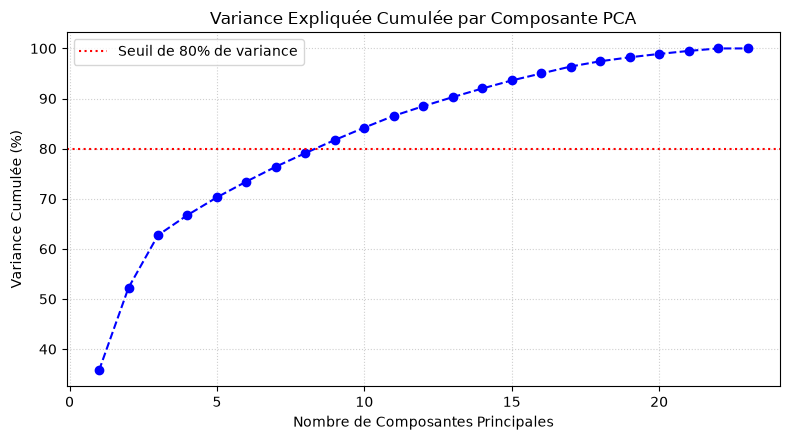

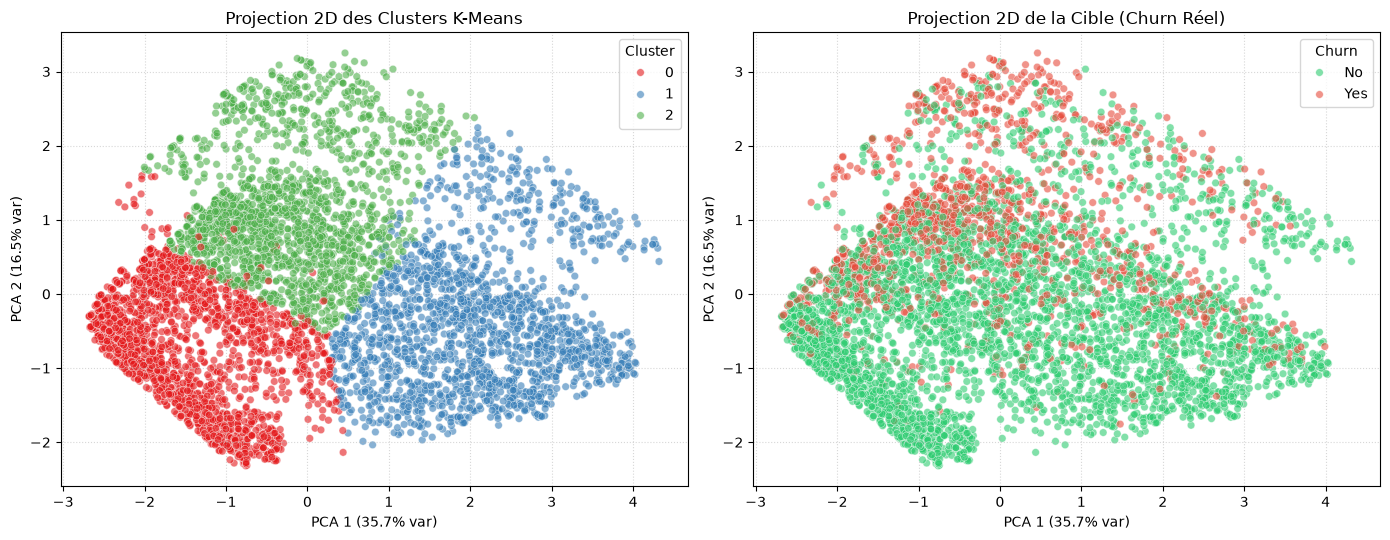

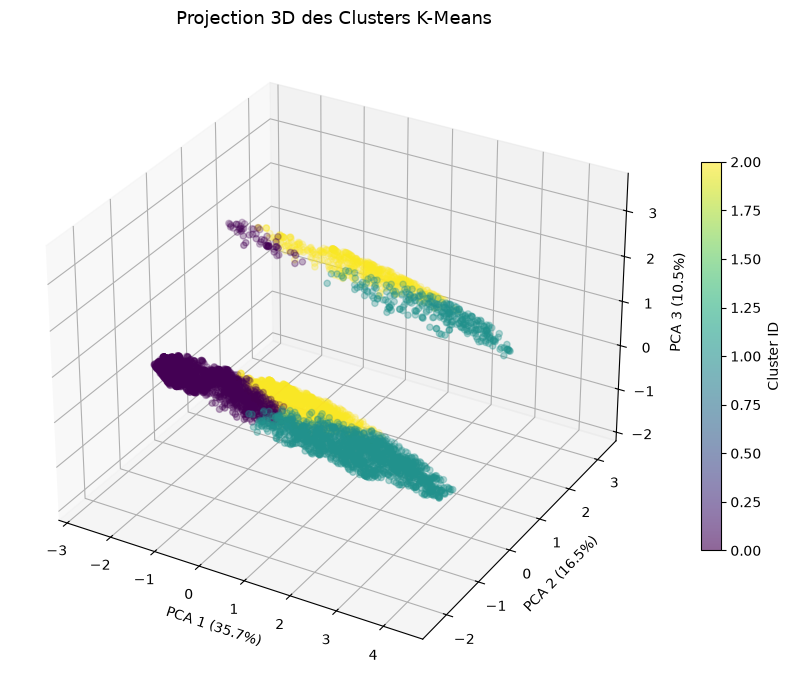

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

# ---------------------------------------------------------
# 1. ANALYSE DE LA VARIANCE EXPLIQUÉE PAR LA PCA
# ---------------------------------------------------------

# PCA sur toutes les composantes pour analyser la variance
pca_full = PCA(random_state=42)
pca_full.fit(x_train_scaled)

cum_variance = np.cumsum(pca_full.explained_variance_ratio_) * 100

plt.figure(figsize=(8, 4.5))
plt.plot(range(1, len(cum_variance) + 1), cum_variance, marker='o', linestyle='--', color='b')
plt.axhline(y=80, color='r', linestyle=':', label='Seuil de 80% de variance')
plt.title('Variance Expliquée Cumulée par Composante PCA', fontsize=12)
plt.xlabel('Nombre de Composantes Principales', fontsize=10)
plt.ylabel('Variance Cumulée (%)', fontsize=10)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 2. PROJECTION PCA EN 2D (PAR CLUSTER ET PAR CHURN)
# ---------------------------------------------------------

# PCA réduite à 2 dimensions
pca_2d = PCA(n_components=2, random_state=42)
X_train_pca_2d = pca_2d.fit_transform(x_train_scaled)

var_1 = pca_2d.explained_variance_ratio_[0] * 100
var_2 = pca_2d.explained_variance_ratio_[1] * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# Graphique A : PCA colorée par Clusters (K-Means)
sns.scatterplot(
    x=X_train_pca_2d[:, 0], y=X_train_pca_2d[:, 1],
    hue=x_train['Cluster'], palette='Set1',
    alpha=0.6, s=30, ax=axes[0]
)
axes[0].set_title('Projection 2D des Clusters K-Means', fontsize=12)
axes[0].set_xlabel(f'PCA 1 ({var_1:.1f}% var)', fontsize=10)
axes[0].set_ylabel(f'PCA 2 ({var_2:.1f}% var)', fontsize=10)
axes[0].grid(True, linestyle=':', alpha=0.5)

# Graphique B : PCA colorée par Churn Réel
sns.scatterplot(
    x=X_train_pca_2d[:, 0], y=X_train_pca_2d[:, 1],
    hue=y_train, palette=['#2ecc71', '#e74c3c'],
    alpha=0.6, s=30, ax=axes[1]
)
axes[1].set_title('Projection 2D de la Cible (Churn Réel)', fontsize=12)
axes[1].set_xlabel(f'PCA 1 ({var_1:.1f}% var)', fontsize=10)
axes[1].set_ylabel(f'PCA 2 ({var_2:.1f}% var)', fontsize=10)
axes[1].grid(True, linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 3. PROJECTION PCA EN 3D (INTERACTIVE / VISUELLE)
# ---------------------------------------------------------

pca_3d = PCA(n_components=3, random_state=42)
X_train_pca_3d = pca_3d.fit_transform(x_train_scaled)

fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    X_train_pca_3d[:, 0], 
    X_train_pca_3d[:, 1], 
    X_train_pca_3d[:, 2], 
    c=x_train['Cluster'], 
    cmap='viridis', 
    s=20, 
    alpha=0.6
)

ax.set_title('Projection 3D des Clusters K-Means', fontsize=13)
ax.set_xlabel(f'PCA 1 ({pca_3d.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PCA 2 ({pca_3d.explained_variance_ratio_[1]*100:.1f}%)')
ax.set_zlabel(f'PCA 3 ({pca_3d.explained_variance_ratio_[2]*100:.1f}%)')

plt.colorbar(scatter, ax=ax, label='Cluster ID', shrink=0.6)
plt.tight_layout()
plt.show()

In [17]:
# import joblib

# joblib.dump(prep, '../models/clustering/preprocessor.pkl')
# joblib.dump(model_final, '../models/clustering/kmeans_churn_model.pkl')
# print("Modèle et préprocesseur sauvegardés avec succès !")

In [18]:
# 1. Profil des variables numériques
print(x_train.groupby('Cluster')[num_cols].mean())

# 2. Proportion de Churn par cluster
print(x_train.groupby('Cluster')['Churn'].value_counts(normalize=True).unstack())

         SeniorCitizen     tenure  MonthlyCharges  TotalCharges
Cluster                                                        
0             0.026807  26.027764       31.532145    776.217975
1             0.179487  58.608974       89.994085   5275.769056
2             0.296337  15.005467       79.357408   1208.701176
Churn          No       Yes
Cluster                    
0        0.848731  0.151269
1        0.853147  0.146853
2        0.492619  0.507381
